In [ ]:
import os, sys, joblib, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              recall_score, confusion_matrix)

try:
    _nb = globals().get('__vsc_ipynb_file__')
    if _nb:
        os.chdir(os.path.dirname(os.path.dirname(_nb)))
except Exception:
    pass

%load_ext autoreload
%autoreload 2
import config
%matplotlib inline

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'grid.linestyle': '--',
    'grid.alpha': 0.7,
    'font.size': 10,
})
print("CWD:", os.getcwd())



[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0

CWD: /vol/bitbucket/gk225/POC_DDM/gk_code/main


In [2]:
sys.path.insert(0, 'utils')
sys.path.insert(0, 'utils/model_training')
from model_utils import build_well_stratified_random_split, build_well_stratified_nfold_splits
from sklearn.preprocessing import LabelEncoder

def reconstruct_well_splits(y_full, well_ids_full, mask=None, n_splits=1, random_state=0):
    """Replays evaluate_outlier_filters' own mask -> rare-class-drop -> well-stratified-split
    procedure (utils/model_training/model_utils.py:863-916) exactly, so the returned test-set
    well_ids line up with the cached y_trues_/y_preds_AC_* arrays. mask=None means the
    outlier_filter=None case (no rows removed pre-split). n_splits=1 uses the same
    max(10%, n_wells) test_size floor evaluate_outlier_filters uses for its single-split
    case; n_splits>1 returns that many well-stratified CV folds.
    Returns a list of (y_values_fold, well_ids_fold) pairs, one per fold, in the same
    order as evaluate_outlier_filters' own `splits` list."""
    if mask is None:
        mask = np.ones(len(y_full), dtype=bool)
    y_m, w_m = y_full[mask], well_ids_full[mask]

    unique_classes, class_counts = np.unique(y_m, return_counts=True)
    rare = unique_classes[class_counts < 2]
    valid = ~np.isin(y_m, rare)
    y_v, w_v = y_m[valid], w_m[valid]

    if n_splits == 1:
        n_wells = len(np.unique(w_v))
        test_size = max(len(y_v) * 0.10, n_wells) / len(y_v)
        splits = list(build_well_stratified_random_split(
            y_v, w_v, test_size=test_size, random_state=random_state).values())
    else:
        actual_splits = min(n_splits, len(np.unique(w_v)))
        splits = list(build_well_stratified_nfold_splits(
            y_v, w_v, n_splits=actual_splits, random_state=random_state).values())

    return [(y_v[test_idx], w_v[test_idx]) for _, test_idx in splits]

def remap_well_splits(well_ids_full, y_full, mask, global_splits):
    """Mirrors _remap_global_splits (utils/model_training/model_utils.py:710) plus the
    rare-class-drop step inside evaluate_outlier_filters, for the cv_splits-supplied path
    used by 04_cross_dataset_training.py's kfold/lofo modes -- where the split is computed
    ONCE on the full (unmasked) pool and then masked/remapped per outlier filter, rather
    than split fresh per filter like reconstruct_well_splits above.
    global_splits: dict or list of (train_idx, test_idx) pairs in full-pool index space.
    Returns a dict/list (matching global_splits' own container type) of
    (y_values_fold, well_ids_fold) pairs."""
    kept_global = np.where(mask)[0]
    y_m, w_m = y_full[mask], well_ids_full[mask]
    unique_classes, class_counts = np.unique(y_m, return_counts=True)
    rare = unique_classes[class_counts < 2]
    valid = ~np.isin(y_m, rare)
    kept_global = kept_global[valid]
    y_v, w_v = y_m[valid], w_m[valid]
    pos_lookup = {g: i for i, g in enumerate(kept_global)}

    def _remap_one(test_idx):
        local_test = np.array([pos_lookup[g] for g in test_idx if g in pos_lookup], dtype=int)
        return y_v[local_test], w_v[local_test]

    if isinstance(global_splits, dict):
        return {k: _remap_one(test_idx) for k, (_, test_idx) in global_splits.items()}
    return [_remap_one(test_idx) for _, test_idx in global_splits]

def well_level_accuracy(y_trues_flat, preds_flat, well_ids_test):
    """Majority-votes each well's pixel predictions into one verdict; accuracy over wells.
    The true label per well should be unanimous (one well = one label) -- a mismatch
    there signals a split-reconstruction bug, not real label noise."""
    wells = np.unique(well_ids_test)
    n_true_mismatch = 0
    correct = 0
    for w in wells:
        m = well_ids_test == w
        true_vals = pd.Series(y_trues_flat[m])
        if true_vals.nunique() > 1:
            n_true_mismatch += 1
        true_label = true_vals.mode()[0]
        pred_label = pd.Series(preds_flat[m]).mode()[0]
        correct += int(true_label == pred_label)
    if n_true_mismatch:
        print(f"  [!] {n_true_mismatch} well(s) had a non-unanimous true label -- "
              f"split reconstruction likely mismatched training.")
    return correct / len(wells), len(wells)

def verified_well_ids(y_true_cached, folds, context=""):
    """folds: list of (y_values_fold, well_ids_fold) pairs (from reconstruct_well_splits /
    remap_well_splits), covering the same rows as y_true_cached once concatenated in fold
    order. Returns the concatenated well_ids only if the concatenated y-values match
    y_true_cached exactly (length AND values) -- otherwise warns and returns None, so a
    reconstruction bug never silently produces a wrong well_accuracy number."""
    if not folds:
        return None
    y_check = np.concatenate([y for y, _ in folds])
    well_ids = np.concatenate([w for _, w in folds])
    if len(y_check) != len(y_true_cached) or not np.array_equal(y_check, y_true_cached):
        print(f"  [!] well-id reconstruction mismatch ({context}) -- skipping well_accuracy.")
        return None
    return well_ids

def verified_well_folds(cached_y_folds, folds, context=""):
    """Per-fold version of verified_well_ids -- for compute_fold_accuracy_stats, which needs
    one well_ids array per fold (not pooled) to compute a mean/std across folds. Returns a
    list of well_ids arrays (same fold order as cached_y_folds) only if every fold's
    y-values match exactly; otherwise warns and returns None."""
    if folds is None or len(folds) != len(cached_y_folds):
        print(f"  [!] well-id reconstruction mismatch ({context}: fold count) -- skipping well_accuracy.")
        return None
    out = []
    for (y_v, w_v), yt in zip(folds, cached_y_folds):
        if len(y_v) != len(yt) or not np.array_equal(y_v, yt):
            print(f"  [!] well-id reconstruction mismatch ({context}) -- skipping well_accuracy.")
            return None
        out.append(w_v)
    return out


In [3]:
FAMILIES = [
            'cnn_gru_dual', 
            'cnn_gru_dual_attn_recon', 
            ]
# SC_LEVELS = [0, 1, 2, 3]
SC_LEVELS = [0]

MODEL_KEY = {
    (fam, 0): fam for fam in FAMILIES
}

MODELS = [MODEL_KEY[(fam, sc)] for sc in SC_LEVELS for fam in FAMILIES]
MODEL_TO_FAMILY = {MODEL_KEY[(fam, sc)]: fam for sc in SC_LEVELS for fam in FAMILIES}

# ── Paths ─────────────────────────────────────────────────────────────────────

EXP_FOLDER = config.FINAL_EXP_FOLDER

TARGET_FOLDERS = config.CROSS_DATASET_GROUPS['final_6_new']

def short_name(folder):
    m = re.search(r'DDM_0(\d)', folder)
    return f'Chip 0{m.group(1)}' if m else folder.split('_U_', 1)[1]

DATASET_NAMES = [short_name(f) for f in TARGET_FOLDERS]

# ── Labels ────────────────────────────────────────────────────────────────────
# Standard model naming, shared across every section of this notebook (RQ2, RQ3.1, RQ3.2)
# and mirrored verbatim in 0_LOFO_INSPECTION.ipynb -- the single source of truth for how a
# model key is displayed on any chart.
FAMILY_LABELS = {
    'cnn_gru_dual': 'CNN-BiGRU',
    'cnn_gru_dual_dann': 'CNN-BiGRU\n+ DANN',
    'cnn_gru_dual_supcon3': 'CNN-BiGRU\n+ Contrastive Loss (SC3)',
    'cnn_gru_dual_pc_recenter': 'CNN-BiGRU\n+ Latent Alignment',

    'cnn_gru_dual_attn_recon':   'CNN-BiGRU + Spatial Attn',
    'cnn_gru_dual_attn_recon_aug': 'CNN-BiGRU + Spatial Attn\n+ Temporal Aug',
    'cnn_gru_dual_attn_recon_dann': 'CNN-BiGRU + Spatial Attn\n+ DANN',
    'cnn_gru_dual_attn_recon_supcon3': 'CNN-BiGRU + Spatial Attn\n+ Contrastive Loss (SC3)',
    'cnn_gru_dual_attn_recon_pc_recenter': 'CNN-BiGRU + Spatial Attn\n+ Latent Alignment',

    'cnn_gru_dual_cosine_recon': 'CNN-BiGRU + Cosine Recon',
    'ccgd_arch_poc_st': 'CCGD-ST',

    'knn': 'kNN',
    'cnn_gru_dual_attn_recon_dann_pc_recenter': 'CNN-BiGRU + Spatial Attn\n+ DANN + Latent Alignment',
    'cnn_gru_dual_attn_recon_supcon3_pc_recenter': 'CNN-BiGRU + Spatial Attn\n+ Contrastive Loss (SC3) + Latent Alignment',
    'cnn_gru_dual_attn_recon_aug_pc_recenter': 'CNN-BiGRU + Spatial Attn\n+ Temporal Aug + Latent Alignment',
    'cnn_gru_dual_attn_recon_mtl': 'CNN-BiGRU + Spatial Attn\n+ MTL',
    'cnn_gru_dual_attn_recon_mtl_pc_recenter': 'CNN-BiGRU + Spatial Attn\n+ MTL + Latent Alignment',
    'cnn_gru_dual_attn_recon_coral': 'CNN-BiGRU + Spatial Attn\n+ CORAL',
    'cnn_gru_dual_attn_recon_coral_pc_recenter': 'CNN-BiGRU + Spatial Attn\n+ CORAL + Latent Alignment',
}

# ── Colors ────────────────────────────────────────────────────────────────────
# dataviz-skill validated categorical palette, assigned in a `models`-list's order --
# shared by every grouped-bar-by-model chart in this notebook (RQ2 and RQ3.1 alike).
PALETTE = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100',
           '#e87ba4', '#008300', '#4a3aa7', '#e34948']

print(f"{len(MODELS)} models defined.")
print("  " + "\n  ".join(MODELS))


2 models defined.
  cnn_gru_dual
  cnn_gru_dual_attn_recon


In [4]:
TARGET_FOLDERS

['D20260827_E00_C00_F4500KHz_U_DDM_01_final_final',
 'D20260827_E00_C00_F4500KHz_U_DDM_02_final_final',
 'D20260827_E00_C00_F4500KHz_U_DDM_03_final_final',
 'D20260827_E00_C00_F4500KHz_U_DDM_04_final_final',
 'D20260825_E00_C00_F4500KHz_U_DDM_05_01',
 'D20260825_E00_C00_F4500KHz_U_DDM_06_02']

In [5]:
def compute_metrics(perf, model_key, well_ids=None):
    """Return dict with accuracy/f1/auc/sensitivity/specificity, or None if missing.
    well_ids (optional): array aligned 1:1 with concatenate(perf['y_trues_']) -- adds
    well_accuracy/n_wells (majority-vote-per-well accuracy) alongside the pixel-level
    metrics above. Pass an already length/value-verified array (see verified_well_ids)."""
    pred_k = f'y_preds_AC_{model_key}_'
    prob_k = f'y_probs_AC_{model_key}_'
    if pred_k not in perf:
        return None

    y_true  = np.concatenate(perf['y_trues_'])
    y_pred  = np.concatenate(perf[pred_k])
    y_probs = np.concatenate(perf[prob_k]) if prob_k in perf else None
    n_cls   = len(np.unique(y_true))

    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    sens = recall_score(y_true, y_pred, average='macro', zero_division=0)

    if y_probs is not None and n_cls > 1:
        try:
            auc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')
        except Exception:
            auc = np.nan
    else:
        auc = np.nan

    # Specificity = TN/(TN+FP) per class, macro-averaged
    cm = confusion_matrix(y_true, y_pred)
    specs = []
    for i in range(n_cls):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - cm[i, :].sum() - fp
        specs.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)

    out = {'accuracy': acc, 'f1': f1, 'auc': auc,
           'sensitivity': sens, 'specificity': float(np.mean(specs))}

    if well_ids is not None:
        well_acc, n_wells = well_level_accuracy(y_true, y_pred, well_ids)
        out['well_accuracy'] = well_acc
        out['n_wells'] = n_wells

    return out


In [6]:
def macro_f1_sens_spec(y_true, y_pred):
    """F1/sensitivity (recall) macro-averaged, plus specificity (TN/(TN+FP) per class,
    macro-averaged) -- the exact computation compute_metrics uses on a single pooled
    split, factored out so compute_fold_accuracy_stats/load_cv_accuracy can call it once
    per fold instead (giving a real mean/std across folds rather than one pooled value)."""
    n_cls = len(np.unique(y_true))
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    sens = recall_score(y_true, y_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    specs = []
    for i in range(n_cls):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - cm[i, :].sum() - fp
        specs.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)
    return f1, sens, float(np.mean(specs))


# RQ3.1: CROSS VALIDATION

In [7]:
import importlib

# Reuse 06b's own results-file discovery instead of reimplementing it, so this
# section always matches what 06b_cross_dataset_prediction_report.py actually reads.
b06 = importlib.import_module("06b_cross_dataset_prediction_report")
# combine_group/build_nfold_splits/is_amplifying_mask -- reused as-is (not reimplemented)
# to reconstruct well_ids for well_accuracy below, so it stays exactly in sync with how
# 04_cross_dataset_training.py itself builds the kfold5 pool/splits/noamp_remove mask.
p04 = importlib.import_module("04_cross_dataset_training")

CV_MODE_STR    = "kfold5"
CV_FILTER      = "noamp_remove"
CV_CURVE_TYPES = ["ori_curve_sg_p4_norm"]
CV_CURVE_SHORT = {"ori_curve_sg_p4_norm": "sgp4_norm"}
CV_TRAIN_CENTER_FRAC = 0.5  # matches --train_center_frac on f_k5_g13.sh

def cv_group_dir(group_name):
    return Path(EXP_FOLDER) / "cross_dataset_cv" / group_name

def load_cv_results(group_name, curve_type, train_center_frac=CV_TRAIN_CENTER_FRAC):
    group_dir = cv_group_dir(group_name)
    print(group_dir)
    legacy_path = b06.find_results_path(group_dir, CV_MODE_STR, curve_type)
    print(legacy_path)
    return b06.load_partitioned(group_dir, CV_MODE_STR, curve_type, legacy_path=legacy_path,
                                train_center_frac=train_center_frac)


In [8]:
CV_MODELS = ['knn', 'cnn_gru_dual', 'cnn_gru_dual_attn_recon']

def _cv_well_folds(group_name, curve_type):
    """Test-set well_ids for every fold_x of this group/curve_type's kfold5 split, mirroring
    04_cross_dataset_training.py's kfold path exactly: combine_group() -> build_nfold_splits()
    on the full unmasked pool, then remap_well_splits() through the noamp_remove mask (the
    only outlier_filter this section evaluates, CV_FILTER). Returns None if well_ids weren't
    available for this group (missing pixel coords)."""
    exp_paths = [Path(EXP_FOLDER, name) for name in config.CROSS_DATASET_GROUPS[group_name]]
    combined = p04.combine_group(exp_paths, group_name, curve_type=curve_type)
    if combined is None:
        print(f"  [!] {group_name}/{curve_type}: combine_group() returned nothing -- well_accuracy skipped.")
        return None
    if combined["well_ids"] is None:
        print(f"  [!] {group_name}/{curve_type}: no pixel_row_idx/pixel_col_idx metadata (well_ids unavailable) -- well_accuracy skipped.")
        return None
    y_full = LabelEncoder().fit_transform(combined["Y_mapped"])
    cv_splits = p04.build_nfold_splits(y_full, well_ids=combined["well_ids"], n_splits=5)
    mask = (p04.is_amplifying_mask(combined["curves"]) if CV_FILTER == p04.NOAMP_FILTER_NAME
            else np.ones(len(y_full), dtype=bool))
    return remap_well_splits(combined["well_ids"], y_full, mask, cv_splits)


def load_cv_accuracy(group_indices=None, train_center_frac=CV_TRAIN_CENTER_FRAC):
    if group_indices is not None:
        groups = [list(config.CROSS_DATASET_GROUPS)[i] for i in group_indices]
    else:
        groups = list(config.CROSS_DATASET_GROUPS)

    rows = []
    for group_name in groups:
        for curve_type in CV_CURVE_TYPES:
            lofo_results = load_cv_results(group_name, curve_type, train_center_frac=train_center_frac)
            if not lofo_results:
                print(f"[WARN] No results for group {group_name} / curve {curve_type}")
                continue
            fold_labels = sorted([k for k in lofo_results if k.startswith("fold_")],
                                  key=lambda s: int(s.split("_")[1]))

            # Prefer well_ids_test_ (saved directly by evaluate_outlier_filters -- see
            # utils/model_training/model_utils.py) over replaying the split. Only pay for
            # _cv_well_folds' group-pool rebuild if at least one fold still lacks the new key.
            _needs_legacy = any(
                lofo_results[fold].get(CV_FILTER, {}).get('well_ids_test_') is None
                for fold in fold_labels if lofo_results[fold].get(CV_FILTER) is not None
            )
            well_folds = None
            if _needs_legacy:
                try:
                    well_folds = _cv_well_folds(group_name, curve_type)
                except Exception as e:
                    print(f"  [!] {group_name}/{curve_type}: could not reconstruct well_ids ({e}) -- well_accuracy skipped.")
                    well_folds = None

            for fold in fold_labels:
                res_entry = lofo_results[fold].get(CV_FILTER)
                if res_entry is None:
                    continue
                y_true_full = np.concatenate(res_entry["y_trues_"])
                saved_well_ids = res_entry.get('well_ids_test_')
                if saved_well_ids is not None:
                    well_ids_test = np.concatenate(saved_well_ids)
                else:
                    well_ids_test = (verified_well_ids(y_true_full, [well_folds[fold]],
                                                       context=f'{group_name}/{curve_type}/{fold}')
                                     if well_folds is not None and fold in well_folds else None)
                for model in CV_MODELS:
                    preds_key = config.MODEL_KEY_MAP.get(model, (None,))[0]
                    if preds_key is None or preds_key not in res_entry:
                        continue
                    y_pred = np.concatenate(res_entry[preds_key])
                    f1, sens, spec = macro_f1_sens_spec(y_true_full, y_pred)
                    row = dict(group=group_name, curve_type=CV_CURVE_SHORT.get(curve_type, curve_type),
                              fold=fold, model=model, family=MODEL_TO_FAMILY.get(model, model),
                              accuracy=accuracy_score(y_true_full, y_pred) * 100,
                              f1=f1 * 100, sensitivity=sens * 100, specificity=spec * 100,
                              n_test=len(y_true_full), well_accuracy=np.nan, n_wells=np.nan)
                    if well_ids_test is not None:
                        well_acc, n_wells = well_level_accuracy(y_true_full, y_pred, well_ids_test)
                        row["well_accuracy"] = well_acc * 100
                        row["n_wells"] = n_wells
                    rows.append(row)
    # Explicit columns so an empty result (e.g. train_center_frac results not
    # finished training yet) still has 'group'/'curve_type' etc. to groupby --
    # otherwise a 0-row, 0-column DataFrame KeyErrors every downstream groupby.
    return pd.DataFrame(rows, columns=['group', 'curve_type', 'fold', 'model', 'family', 'accuracy', 'f1', 'sensitivity', 'specificity', 'n_test', 'well_accuracy', 'n_wells'])

cv_df = load_cv_accuracy(group_indices=[list(config.CROSS_DATASET_GROUPS).index('final_6_new')])
if cv_df.empty:
    print("Loaded 0 rows -- no kfold5 CV results found for the requested groups/curve types.")
else:
    print(f"Loaded {len(cv_df)} rows  |  "
          f"{cv_df.group.nunique()} groups  "
          f"{cv_df.curve_type.nunique()} curve types  "
          f"{cv_df.fold.nunique()} folds  "
          f"{cv_df.model.nunique()} models")
cv_df.head(8)


/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final/cross_dataset_cv/final_6_new
None


Loaded 10 rows  |  1 groups  1 curve types  5 folds  2 models


,group,curve_type,fold,model,family,accuracy,f1,sensitivity,specificity,n_test,well_accuracy,n_wells
0,final_6_new,sgp4_norm,fold_0,cnn_gru_dual,cnn_gru_dual,67.491227,67.466513,67.466291,91.875146,17383,89.361702,47
1,final_6_new,sgp4_norm,fold_0,cnn_gru_dual_attn_recon,cnn_gru_dual_attn_recon,95.921302,95.940935,95.902629,98.975755,17383,100.000000,47
2,final_6_new,sgp4_norm,fold_1,cnn_gru_dual,cnn_gru_dual,66.821439,66.829012,66.697575,91.708697,17445,89.361702,47
3,final_6_new,sgp4_norm,fold_1,cnn_gru_dual_attn_recon,cnn_gru_dual_attn_recon,96.680997,96.697101,96.695407,99.168447,17445,100.000000,47
4,final_6_new,sgp4_norm,fold_2,cnn_gru_dual,cnn_gru_dual,69.728829,69.786535,69.649721,92.429671,17406,91.489362,47
5,final_6_new,sgp4_norm,fold_2,cnn_gru_dual_attn_recon,cnn_gru_dual_attn_recon,95.461335,95.482282,95.473292,98.862945,17406,100.000000,47
6,final_6_new,sgp4_norm,fold_3,cnn_gru_dual,cnn_gru_dual,68.779086,68.631177,68.729771,92.198351,17405,93.617021,47
7,final_6_new,sgp4_norm,fold_3,cnn_gru_dual_attn_recon,cnn_gru_dual_attn_recon,96.185004,96.197725,96.200497,99.045197,17405,100.000000,47


In [9]:
cv_expected = len(CV_MODELS)
cv_check = (cv_df.groupby(['group', 'curve_type', 'fold'])
              .size()
              .reset_index(name='n')
              .assign(expected=cv_expected, ok=lambda x: x.n == x.expected))
cv_missing = cv_check[~cv_check.ok]
if cv_missing.empty:
    print("All CV combinations fully populated.")
else:
    print("[!] Incomplete CV combinations (job likely still running):")
    display(cv_missing)


[!] Incomplete CV combinations (job likely still running):


,group,curve_type,fold,n,expected,ok
0,final_6_new,sgp4_norm,fold_0,2,3,False
1,final_6_new,sgp4_norm,fold_1,2,3,False
2,final_6_new,sgp4_norm,fold_2,2,3,False
3,final_6_new,sgp4_norm,fold_3,2,3,False
4,final_6_new,sgp4_norm,fold_4,2,3,False


In [10]:
def plot_grouped_bar_by_model(df, x_col, x_order, models, model_labels,
                               value_col='accuracy', value_label=None, xlabel='', title='', figsize=(10, 6), plot_fold=True, plot_summary=True, show_std=True):

    n_models = len(models)
    ylabel = value_label or f'{value_col.replace("_", " ").title()} (%)'

    if plot_fold:
        bar_w = 0.8 / n_models
        x = np.arange(len(x_order))

        fig, ax = plt.subplots(figsize=figsize)
        for mi, model in enumerate(models):
            sub = df[df.model == model].set_index(x_col)[value_col]
            ys = np.array([sub.get(v, np.nan) for v in x_order])
            offset = (mi - (n_models - 1) / 2) * bar_w
            ax.bar(x + offset, np.nan_to_num(ys, nan=0), width=bar_w,
                color=PALETTE[mi % len(PALETTE)],
                label=model_labels.get(model, model),
                edgecolor='white', linewidth=0.8)
            for xi, yi in zip(x + offset, ys):
                if not np.isnan(yi):
                    ax.text(xi, yi + 0.5, f'{yi:.2f}', ha='center', va='bottom', fontsize=8)

        ax.set_xticks(x)
        ax.set_xticklabels(x_order)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_ylim(0, 108)
        ax.legend(title='Model', fontsize=8, loc='lower right', framealpha=0.9, bbox_to_anchor=(1.5,0))
        ax.set_title(title, fontsize=11, fontweight='bold')
        fig.tight_layout()
        plt.show()

    stats = df.groupby('model')[value_col].agg(['mean', 'std']).reindex(models)

    if plot_summary:
        mean_v = stats['mean'].to_numpy()
        std_v  = np.nan_to_num(stats['std'].to_numpy(), nan=0)
        x2 = np.arange(n_models)

        fig2, ax2 = plt.subplots(figsize=(0.75 * n_models + 2, 6))
        if show_std:
            ax2.bar(x2, np.nan_to_num(mean_v, nan=0), yerr=std_v, capsize=4,
                color=[PALETTE[mi % len(PALETTE)] for mi in range(n_models)],
                edgecolor='white', linewidth=0.8,
                error_kw=dict(ecolor='#3a3a3a', elinewidth=1.2))
        else:
            ax2.bar(x2, np.nan_to_num(mean_v, nan=0),
                color=[PALETTE[mi % len(PALETTE)] for mi in range(n_models)],
                edgecolor='white', linewidth=0.8)
        for xi, mv, sv in zip(x2, mean_v, std_v):
            if np.isnan(mv):
                continue
            # ax2.text(xi, mv + sv + 0.5, f'{mv:.2f} \u00b1 {sv:.2f}', ha='center', va='bottom', fontsize=12)
            if show_std:
                ax2.text(xi, mv + sv + 0.5, f'{mv:.2f} \u00b1 {sv:.2f}', ha='center', va='bottom', fontsize=11)
            else:
                ax2.text(xi, mv + 0.5, f'{mv:.2f}', ha='center', va='bottom', fontsize=11)

        ax2.set_xticks(x2)
        ax2.set_xticklabels([model_labels.get(m, m) for m in models], fontsize=9, rotation=30, ha='right')
        ax2.set_ylabel(ylabel)
        ax2.set_ylim(0, 108)
        ax2.set_title(f'{title}\nMean \u00b1 std across {len(x_order)} {xlabel.lower()}s',
                    fontsize=11, fontweight='bold')
        fig2.tight_layout()
        plt.show()
    return stats


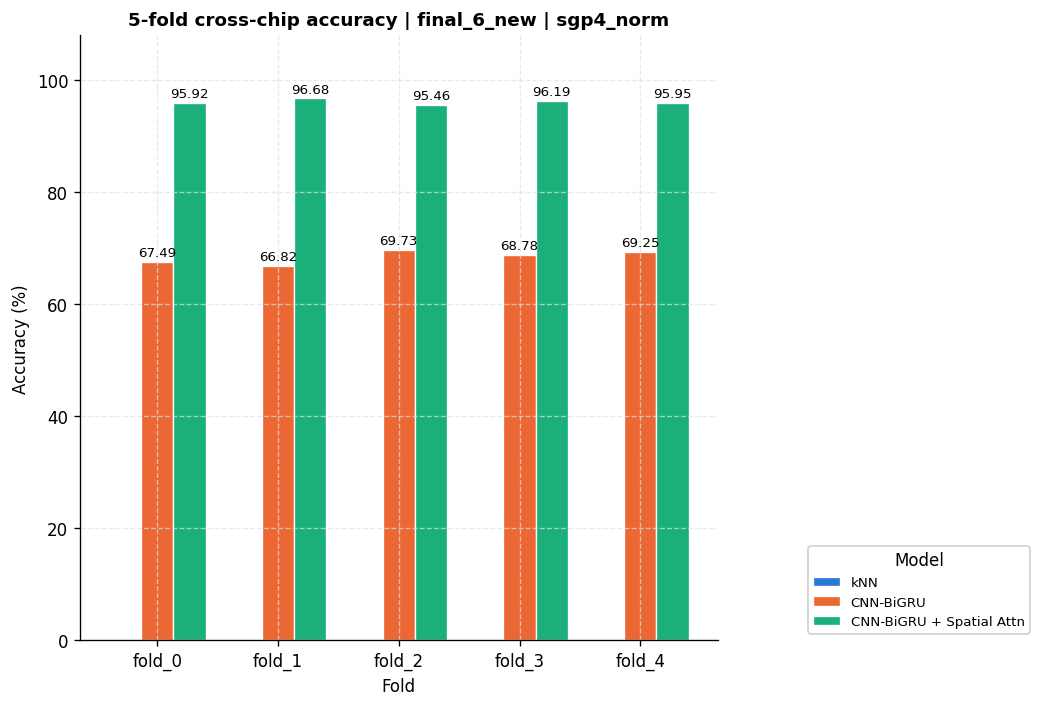

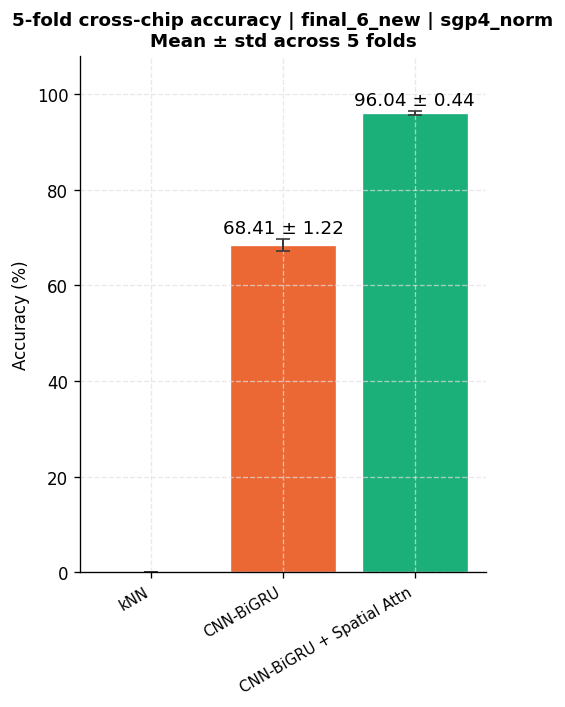


Mean ± std across folds (final_6_new | sgp4_norm):
                          mean   std
model                               
knn                        NaN   NaN
cnn_gru_dual             68.41  1.22
cnn_gru_dual_attn_recon  96.04  0.44


In [11]:
%matplotlib inline

for (group_name, curve_type), sub in cv_df.groupby(['group', 'curve_type']):
    fold_labels = sorted(sub.fold.unique(), key=lambda s: int(s.split('_')[1]))
    stats = plot_grouped_bar_by_model(
        sub, x_col='fold', x_order=fold_labels, models=CV_MODELS, model_labels=FAMILY_LABELS,
        xlabel='Fold', title=f'5-fold cross-chip accuracy | {group_name} | {curve_type}',
    )
    print(f"\nMean ± std across folds ({group_name} | {curve_type}):")
    print(stats.round(2))


In [12]:
CV_MODELS

['knn', 'cnn_gru_dual', 'cnn_gru_dual_attn_recon']

### LaTeX table -- CV (final_6_new, SG p=4 norm), kNN vs. CNN-BiGRU vs. + Spatial Attn

Single table (one group/curve_type already, no per-dataset panels needed): rows = the
3 model variants, columns = Overall (Accuracy, F1) / Macro Averages (Sensitivity,
Specificity), each mean $\pm$ std across the 5 CV folds.


In [13]:
def build_cv_latex_table(cv_df, group_name, curve_type, models, model_labels, caption, label):
    sub = cv_df[(cv_df.group == group_name) & (cv_df.curve_type == curve_type)
                & cv_df.model.isin(models)]
    metrics = ['accuracy', 'f1', 'sensitivity', 'specificity']
    stats = sub.groupby('model')[metrics].agg(['mean', 'std']).reindex(models)
    best = {m: stats[(m, 'mean')].idxmax() for m in metrics}

    lines = [
        '\\begin{table}[htbp]',
        '    \\centering',
        f'    \\caption{{{caption}}}',
        f'    \\label{{{label}}}',
        '    \\small',
        '',
        '    \\resizebox{\\textwidth}{!}{',
        '    \\begin{tabular}{lrrrr}',
        '    \\toprule',
        '     & \\multicolumn{2}{c}{\\textbf{Overall}} & \\multicolumn{2}{c}{\\textbf{Macro Averages}} \\\\',
        '    \\cmidrule(lr){2-3} \\cmidrule(lr){4-5}',
        '    \\textbf{Model} & \\textbf{Accuracy} & \\textbf{F1} & \\textbf{Sensitivity} & \\textbf{Specificity} \\\\',
        '    \\midrule',
    ]
    for model in models:
        cells = []
        for m in metrics:
            v = f"{stats.loc[model, (m, 'mean')]:.2f}\\% $\\pm$ {stats.loc[model, (m, 'std')]:.2f}\\%"
            if best[m] == model:
                v = f'\\textbf{{{v}}}'
            cells.append(v)
        row_label = model_labels.get(model, model).replace(chr(10), ' ')
        lines.append(f'    {row_label} & {" & ".join(cells)} \\\\')
    lines += ['    \\bottomrule', '    \\end{tabular}', '    }', '\\end{table}']
    return '\n'.join(lines)


cv_latex = build_cv_latex_table(
    cv_df, group_name='final_6_new', curve_type='sgp4_norm',
    models=CV_MODELS, model_labels=FAMILY_LABELS,
    caption=('5-fold cross-chip validation performance on final\\_6\\_new '
             '(SG p=4, normalized), reported as mean $\\pm$ standard deviation across folds. '
             'Bold marks the best result per metric.'),
    label='tab:cv_final6_new_sgp4norm',
)
print(cv_latex)


\begin{table}[htbp]
    \centering
    \caption{5-fold cross-chip validation performance on final\_6\_new (SG p=4, normalized), reported as mean $\pm$ standard deviation across folds. Bold marks the best result per metric.}
    \label{tab:cv_final6_new_sgp4norm}
    \small

    \resizebox{\textwidth}{!}{
    \begin{tabular}{lrrrr}
    \toprule
     & \multicolumn{2}{c}{\textbf{Overall}} & \multicolumn{2}{c}{\textbf{Macro Averages}} \\
    \cmidrule(lr){2-3} \cmidrule(lr){4-5}
    \textbf{Model} & \textbf{Accuracy} & \textbf{F1} & \textbf{Sensitivity} & \textbf{Specificity} \\
    \midrule
    kNN & nan\% $\pm$ nan\% & nan\% $\pm$ nan\% & nan\% $\pm$ nan\% & nan\% $\pm$ nan\% \\
    CNN-BiGRU & 68.41\% $\pm$ 1.22\% & 68.37\% $\pm$ 1.21\% & 68.33\% $\pm$ 1.22\% & 92.10\% $\pm$ 0.30\% \\
    CNN-BiGRU + Spatial Attn & \textbf{96.04\% $\pm$ 0.44\%} & \textbf{96.06\% $\pm$ 0.44\%} & \textbf{96.06\% $\pm$ 0.45\%} & \textbf{99.01\% $\pm$ 0.11\%} \\
    \bottomrule
    \end{tabular}
    }
\end

### LaTeX table -- CV per-class Sensitivity/Specificity (appendix, landscape)

In [14]:
def get_group_class_names(group_name, curve_type, train_center_frac=CV_TRAIN_CENTER_FRAC):
    lofo_results = load_cv_results(group_name, curve_type, train_center_frac=train_center_frac)
    for fold in lofo_results:
        cn = lofo_results[fold].get('class_names')
        if cn:
            return list(cn)
    return []


def compute_cv_per_class_sens_spec(group_name, curve_type, model, class_names,
                                   train_center_frac=CV_TRAIN_CENTER_FRAC):
    lofo_results = load_cv_results(group_name, curve_type, train_center_frac=train_center_frac)
    fold_labels = sorted([k for k in lofo_results if k.startswith("fold_")], key=lambda s: int(s.split("_")[1]))
    preds_key = config.MODEL_KEY_MAP.get(model, (None,))[0]
    if preds_key is None:
        return None
    n_cls = len(class_names)
    fold_sens, fold_spec = [], []
    for fold in fold_labels:
        res_entry = lofo_results[fold].get(CV_FILTER)
        if res_entry is None or preds_key not in res_entry:
            continue
        y_true = np.concatenate(res_entry["y_trues_"])
        y_pred = np.concatenate(res_entry[preds_key])
        cm = confusion_matrix(y_true, y_pred, labels=range(n_cls))
        sens_c, spec_c = [], []
        for i in range(n_cls):
            tp = cm[i, i]
            fn = cm[i, :].sum() - tp
            fp = cm[:, i].sum() - tp
            tn = cm.sum() - tp - fn - fp
            sens_c.append(tp / (tp + fn) if (tp + fn) > 0 else np.nan)
            spec_c.append(tn / (tn + fp) if (tn + fp) > 0 else np.nan)
        fold_sens.append(sens_c)
        fold_spec.append(spec_c)
    if not fold_sens:
        return None
    fold_sens = np.array(fold_sens, dtype=float)
    fold_spec = np.array(fold_spec, dtype=float)
    return {
        'sens_mean': np.nanmean(fold_sens, axis=0) * 100, 'sens_std': np.nanstd(fold_sens, axis=0) * 100,
        'spec_mean': np.nanmean(fold_spec, axis=0) * 100, 'spec_std': np.nanstd(fold_spec, axis=0) * 100,
    }


def build_cv_per_class_latex_table(group_name, curve_type, models, model_labels, class_names, caption, label):
    per_model = {}
    for m in models:
        stats = compute_cv_per_class_sens_spec(group_name, curve_type, m, class_names)
        if stats is not None:
            per_model[m] = stats
    models_here = [m for m in models if m in per_model]

    model_header = ' & '.join(
        f'\\multicolumn{{2}}{{c}}{{\\textbf{{{model_labels.get(m, m).replace(chr(10), " ")}}}}}'
        for m in models_here)
    model_cmid = ' '.join(f'\\cmidrule(lr){{{2 + 2*i}-{3 + 2*i}}}' for i in range(len(models_here)))
    metric_row = ' & '.join('\\textbf{Sens.} & \\textbf{Spec.}' for _ in models_here)

    lines = [
        '\\begin{landscape}',
        '\\begin{table}[!htbp]',
        '    \\centering',
        f'    \\caption{{{caption}}}',
        f'    \\label{{{label}}}',
        '    \\small',
        '    \\resizebox{\\textwidth}{!}{',
        '    \\begin{tabular}{l' + 'cc' * len(models_here) + '}',
        '    \\toprule',
        f'     & {model_header} \\\\',
        f'    {model_cmid}',
        f'    \\textbf{{Class}} & {metric_row} \\\\',
        '    \\midrule',
    ]
    for ci, cname in enumerate(class_names):
        sens_vals = {m: per_model[m]['sens_mean'][ci] for m in models_here}
        spec_vals = {m: per_model[m]['spec_mean'][ci] for m in models_here}
        best_sens = max(sens_vals, key=sens_vals.get) if sens_vals else None
        best_spec = max(spec_vals, key=spec_vals.get) if spec_vals else None
        cells = []
        for m in models_here:
            s = per_model[m]
            sens_str = f"{s['sens_mean'][ci]:.2f}\\% $\\pm$ {s['sens_std'][ci]:.2f}\\%"
            spec_str = f"{s['spec_mean'][ci]:.2f}\\% $\\pm$ {s['spec_std'][ci]:.2f}\\%"
            if m == best_sens:
                sens_str = f'\\textbf{{{sens_str}}}'
            if m == best_spec:
                spec_str = f'\\textbf{{{spec_str}}}'
            cells.append(sens_str)
            cells.append(spec_str)
        lines.append(f"    {cname} & " + " & ".join(cells) + " \\\\")
    lines += ['    \\bottomrule', '    \\end{tabular}', '    }', '\\end{table}', '\\end{landscape}']
    return '\n'.join(lines)


cv_class_names = get_group_class_names('final_6_new', 'ori_curve_sg_p4_norm')
cv_per_class_latex = build_cv_per_class_latex_table(
    'final_6_new', 'ori_curve_sg_p4_norm', CV_MODELS, FAMILY_LABELS, cv_class_names,
    caption=('Per-class sensitivity and specificity for 5-fold cross-chip validation on '
             'final\\_6\\_new (SG p=4, normalized). Results are mean $\\pm$ standard deviation '
             'across folds. Bold marks the best result per class.'),
    label='tab:cv_per_class_sens_spec',
)
print(cv_per_class_latex)


/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final/cross_dataset_cv/final_6_new
None


/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final/cross_dataset_cv/final_6_new
None


/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final/cross_dataset_cv/final_6_new
None


/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final/cross_dataset_cv/final_6_new
None


\begin{landscape}
\begin{table}[!htbp]
    \centering
    \caption{Per-class sensitivity and specificity for 5-fold cross-chip validation on final\_6\_new (SG p=4, normalized). Results are mean $\pm$ standard deviation across folds. Bold marks the best result per class.}
    \label{tab:cv_per_class_sens_spec}
    \small
    \resizebox{\textwidth}{!}{
    \begin{tabular}{lcccc}
    \toprule
     & \multicolumn{2}{c}{\textbf{CNN-BiGRU}} & \multicolumn{2}{c}{\textbf{CNN-BiGRU + Spatial Attn}} \\
    \cmidrule(lr){2-3} \cmidrule(lr){4-5}
    \textbf{Class} & \textbf{Sens.} & \textbf{Spec.} & \textbf{Sens.} & \textbf{Spec.} \\
    \midrule
    Cov & 60.40\% $\pm$ 2.66\% & 89.82\% $\pm$ 0.72\% & \textbf{94.86\% $\pm$ 1.15\%} & \textbf{98.71\% $\pm$ 0.28\%} \\
    Hadv & 76.55\% $\pm$ 1.03\% & 92.85\% $\pm$ 0.43\% & \textbf{97.54\% $\pm$ 0.95\%} & \textbf{98.94\% $\pm$ 0.10\%} \\
    IAV & 82.41\% $\pm$ 1.14\% & 96.72\% $\pm$ 0.33\% & \textbf{96.06\% $\pm$ 1.74\%} & \textbf{99.34\% $\pm$ 0.18